In [ ]:
%matplotlib inline
import re
import sys
import os
import json
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer
from underthesea import word_tokenize
import psycopg2

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
WINDOW_DAYS           = 7
MIN_CONTENT_LEN       = 200
MIN_TOKEN_LEN         = 20
SBERT_MODEL           = 'keepitreal/vietnamese-sbert'
SBERT_BATCH_SIZE      = 64
SBERT_CONTENT_CHARS   = 512
SEMANTIC_THRESHOLD    = 0.25
TFIDF_MAX_FEATURES    = 300
TFIDF_MIN_DF          = 2
TFIDF_NGRAM           = (1, 2)
TOP_KEYWORDS          = 30
N_TOPIC_CLUSTERS      = 8
TOP_NEWS_PER_CLUSTER  = 2
TOP_NEWS_GLOBAL       = 15
HIGHLIGHT_TOP_N       = 10
EXEC_SUMMARY_MAX_ARTICLES = 5

In [3]:
TECH_QUERIES = [
    'trí tuệ nhân tạo AI machine learning deep learning mô hình chatgpt openai gemini',
    'điện thoại smartphone iphone samsung chip vi xử lý màn hình camera',
    'phần mềm ứng dụng lập trình code backend frontend framework',
    'an ninh mạng bảo mật dữ liệu hacker tấn công mã hóa',
    'xe điện năng lượng pin sạc xe tự lái ô tô điện',
    'mạng xã hội facebook tiktok youtube instagram người dùng nội dung',
    'khởi nghiệp startup đầu tư gọi vốn định giá IPO',
    'máy tính laptop desktop server chip CPU GPU',
    'blockchain bitcoin ethereum tiền mã hóa crypto',
]

TOPIC_LABELS = [
    'AI / ML',
    'Thiết bị di động',
    'Phần mềm / Dev',
    'An ninh mạng',
    'Xe điện / Năng lượng',
    'Mạng xã hội',
    'Startup / Đầu tư',
    'Phần cứng / Server',
    'Crypto / Blockchain',
]

IMPORTANT_ENGLISH_KEYWORDS = {
    'ai', 'ml', 'llm', 'gpt', 'openai', 'chatgpt', 'github', 'python', 'java',
    'javascript', 'typescript', 'sql', 'api', 'web', 'app', 'ios', 'android',
    'cloud', 'aws', 'azure', 'google', 'meta', 'nvidia', 'tesla', 'apple',
    'samsung', 'iphone', 'bitcoin', 'ethereum', 'blockchain', 'nft', 'metaverse',
    'vr', 'ar', 'iot', 'ota', 'crm', 'erp', 'saas', 'paas', 'iaas', 'edge',
    'quantum', 'chip', '5g', '6g', 'cpu', 'gpu', 'ram', 'ssd', 'usb',
    'wifi', 'bluetooth', 'hdmi', 'usb-c', 'oled', 'amoled',
    'battery', 'megapixel', 'fps', 'tps', 'latency', 'bandwidth',
    'vpn', 'proxy', 'firewall', 'encryption', 'hash', 'zero-day',
    'exploit', 'malware', 'ransomware', 'trojan', 'worm', 'bot', 'ddos',
    'deepseek', 'gemini', 'claude', 'copilot', 'sora', 'mistral', 'llama',
}

STOPWORDS = {
    'một_số','tuy_nhiên','đồng_thời','không_chỉ','thay_vì',
    'trong_khi','bên_cạnh','ngoài_ra','theo_đó','do_đó',
    'vì_vậy','mặc_dù','bởi_vì','chẳng_hạn','hay_là',
    'hơn','sao','tàu','kỳ','tận','ưu','tiên','nhân','ích',
    'gói','bộ','kho','nút','cúp','trẻ','già','gia','chủ',
    'thừa','khuyên','bắt','ép','mách','báo','kể','nói',
    'có_thể','sử_dụng','cho_phép','giúp_đỡ','thực_hiện',
    'xây_dựng','hoạt_động','tiếp_tục','bao_gồm','liên_quan',
    'tham_gia','chia_sẻ','thành_công','hiệu_quả','quan_trọng',
    'trong','của','với','tại','từ','theo','qua','bằng',
    'hay','còn','mà','nếu','khi','vì','để','là','và',
    'ra','vào','đến','lại','đã','sẽ','đang','được','bị',
    'một','những','nhiều','này','đây','các','cùng','đó',
    'như','sau','trên','cho','cần','có','không','làm',
    'người',
    'phát_triển','khả_năng',
    'thông_tin','nội_dung','vấn_đề','trường_hợp','thời_gian',
    'việc','điều','cách','loại','số','mức','lần','công_nghệ',
    'năm','tháng','ngày','tuần','giờ',
    'http','https','www','com','vn','html','utm','org','net',
    'họ','ta','tôi','bạn','chúng','mình','anh','chị',
    'tp','hcm',
    'được','đang','sẽ','đã','phải','cần',
    'dùng','làm','tạo','cho','giúp','trợ','thực','thấy',
    'hoặc','và','nhưng','nếu','vì','nên',
    'mới','cũ','lớn','nhỏ','tốt','xấu','nhanh',
    'dân_trí','vnexpress','thanh_niên','tuổi_trẻ','báo_chí',
    'trang_web','website','công_bố','thông_báo','tin_tức',
    'cũng','chưa','ông','vẫn','chỉ','trước','khác','thêm',
    'đạt', 'đưa',
}

In [ ]:
def get_connection():
    return psycopg2.connect(
        host='localhost',
        port=os.getenv('POSTGRES_PORT'),
        dbname=os.getenv('POSTGRES_DB'),
        user=os.getenv('POSTGRES_USER'),
        password=os.getenv('POSTGRES_PASSWORD'),
    )

conn = get_connection()
df_raw = pd.read_sql('SELECT * FROM articles ORDER BY id', conn)
conn.close()

def fix_text(x):
    if not isinstance(x, str):
        return x
    try:
        return x.encode('latin1').decode('utf-8')
    except Exception:
        return x

for col in ['title', 'content', 'url']:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].apply(fix_text)

MOJIBAKE_PATTERNS = [
    ('latin1_as_utf8', r'Ã©|Ã |Ã¢|Æ°|Ã´|Ã³|Ã¹|Ã'),
    ('broken_sequences', r'â€™|â€œ|â€|â€˜|â€¦'),
]
for col in ['title', 'content']:
    for name, pattern in MOJIBAKE_PATTERNS:
        df_raw[f'{col}_{name}'] = df_raw[col].fillna('').str.contains(pattern, regex=True)
df_raw['has_mojibake'] = False
for col in ['title', 'content']:
    for name, _ in MOJIBAKE_PATTERNS:
        df_raw['has_mojibake'] |= df_raw[f'{col}_{name}']

df_raw['published_at'] = pd.to_datetime(df_raw['published_at'], utc=True, errors='coerce')
df_raw['content_len'] = df_raw['content'].fillna('').str.len()
df_raw['content'] = df_raw['content'].fillna('')
df_raw['title'] = df_raw['title'].fillna('')
df_raw['url'] = df_raw['url'].fillna('')

cutoff = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=WINDOW_DAYS)
df_week = df_raw[df_raw['published_at'] >= cutoff].copy()
df_clean = (
    df_week
    .drop_duplicates(subset=['url'])
    .drop_duplicates(subset=['title'])
    .pipe(lambda d: d[~d['has_mojibake']])
    .pipe(lambda d: d[d['content_len'] >= MIN_CONTENT_LEN])
    .reset_index(drop=True)
)
print(f'Raw DB          : {len(df_raw):,}')
print(f'Past {WINDOW_DAYS} days    : {len(df_week):,}')
print(f'After all filter: {len(df_clean):,}')

Raw DB          : 491
Past 7 days    : 201
After all filter: 158


In [5]:
def clean_text(text: str) -> str:
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text, flags=re.UNICODE)
    text = re.sub(r'\b\d+\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_stopwords(tokenized_text: str) -> str:
    tokens = tokenized_text.split()
    filtered = []
    for t in tokens:
        is_english = t.isascii() and t.isalpha()
        is_important_english = t.lower() in IMPORTANT_ENGLISH_KEYWORDS
        if is_important_english:
            filtered.append(t)
        elif (
            t not in STOPWORDS
            and len(t) > 2
            and not t.isnumeric()
            and not is_english
        ):
            filtered.append(t)
    return ' '.join(filtered)

df_clean['text_raw'] = (df_clean['title'] + ' ' + df_clean['content']).str.lower()
df_clean['text_clean'] = df_clean['text_raw'].apply(clean_text)
df_clean['tokenized_raw'] = df_clean['text_clean'].apply(lambda x: word_tokenize(x, format='text'))
df_clean['tokenized'] = df_clean['tokenized_raw'].apply(remove_stopwords)
df_clean['token_count_after'] = df_clean['tokenized'].str.split().str.len()

df_final = df_clean[df_clean['token_count_after'] >= MIN_TOKEN_LEN].reset_index(drop=True)
print(f'Articles after min-token filter: {len(df_final):,}')

Articles after min-token filter: 158


In [6]:
sbert = SentenceTransformer(SBERT_MODEL)

texts_for_embed = (df_final['title'] + '. ' + df_final['content'].str[:SBERT_CONTENT_CHARS]).tolist()
article_embeddings = sbert.encode(
    texts_for_embed, batch_size=SBERT_BATCH_SIZE, show_progress_bar=True, normalize_embeddings=True
)
query_embeddings = sbert.encode(TECH_QUERIES, normalize_embeddings=True)

sim_matrix = cosine_similarity(article_embeddings, query_embeddings)
df_final = df_final.copy()
df_final['tech_score'] = sim_matrix.max(axis=1)
df_final['tech_topic_idx'] = sim_matrix.argmax(axis=1)
df_final['tech_topic'] = [TOPIC_LABELS[i] for i in df_final['tech_topic_idx']]

tech_mask = df_final['tech_score'] >= SEMANTIC_THRESHOLD
df_tech = df_final[tech_mask].reset_index(drop=True)
tech_embeddings = article_embeddings[tech_mask.values]
print(f'Threshold={SEMANTIC_THRESHOLD} -> {len(df_tech):,} / {len(df_final):,} articles')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 518.93it/s, Materializing param=pooler.dense.weight]                               
RobertaModel LOAD REPORT from: keepitreal/vietnamese-sbert
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 3/3 [00:18<00:00,  6.13s/it]


Threshold=0.25 -> 133 / 158 articles


In [7]:
tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM,
    token_pattern=r'(?u)\b\w\w+\b',
    min_df=TFIDF_MIN_DF,
)
tfidf_matrix = tfidf.fit_transform(df_tech['tokenized'])
tfidf_scores = dict(zip(tfidf.get_feature_names_out(), tfidf_matrix.mean(axis=0).A1))

keyword_embeds = sbert.encode(
    list(tfidf_scores.keys()), normalize_embeddings=True, show_progress_bar=False
)
query_embed_mean = normalize(query_embeddings.mean(axis=0, keepdims=True))
kw_relevance = cosine_similarity(keyword_embeds, query_embed_mean).flatten()

kw_df = pd.DataFrame({
    'keyword': list(tfidf_scores.keys()),
    'tfidf': list(tfidf_scores.values()),
    'semantic': kw_relevance,
})
kw_df['combined'] = kw_df['tfidf'] * kw_df['semantic']
kw_df = kw_df.sort_values('combined', ascending=False).reset_index(drop=True)

top_kw = kw_df.head(TOP_KEYWORDS)
print(f'Top {TOP_KEYWORDS} trending keywords:')
print(top_kw[['keyword', 'tfidf', 'semantic', 'combined']].to_string(index=False))

Top 30 trending keywords:
         keyword    tfidf  semantic  combined
        hệ_thống 0.039192  0.412506  0.016167
           apple 0.074576  0.211210  0.015751
          iphone 0.049507  0.306894  0.015193
        thiết_bị 0.042684  0.332373  0.014187
        nhà_mạng 0.025790  0.515025  0.013283
        ứng_dụng 0.037412  0.339324  0.012695
        sản_phẩm 0.051207  0.213320  0.010924
        màn_hình 0.030172  0.344728  0.010401
             máy 0.024821  0.402693  0.009995
            thuê 0.044177  0.224789  0.009930
              ai 0.070661  0.133991  0.009468
        thiết_kế 0.043546  0.209440  0.009120
            chip 0.023830  0.369539  0.008806
        nền_tảng 0.026472  0.332599  0.008805
      điện_thoại 0.041689  0.204456  0.008524
            dòng 0.033826  0.249000  0.008423
             ios 0.017361  0.466167  0.008093
       tính_năng 0.032470  0.244956  0.007954
      năng_lượng 0.024070  0.321864  0.007747
          google 0.029276  0.262097  0.007673
trí_tuệ 

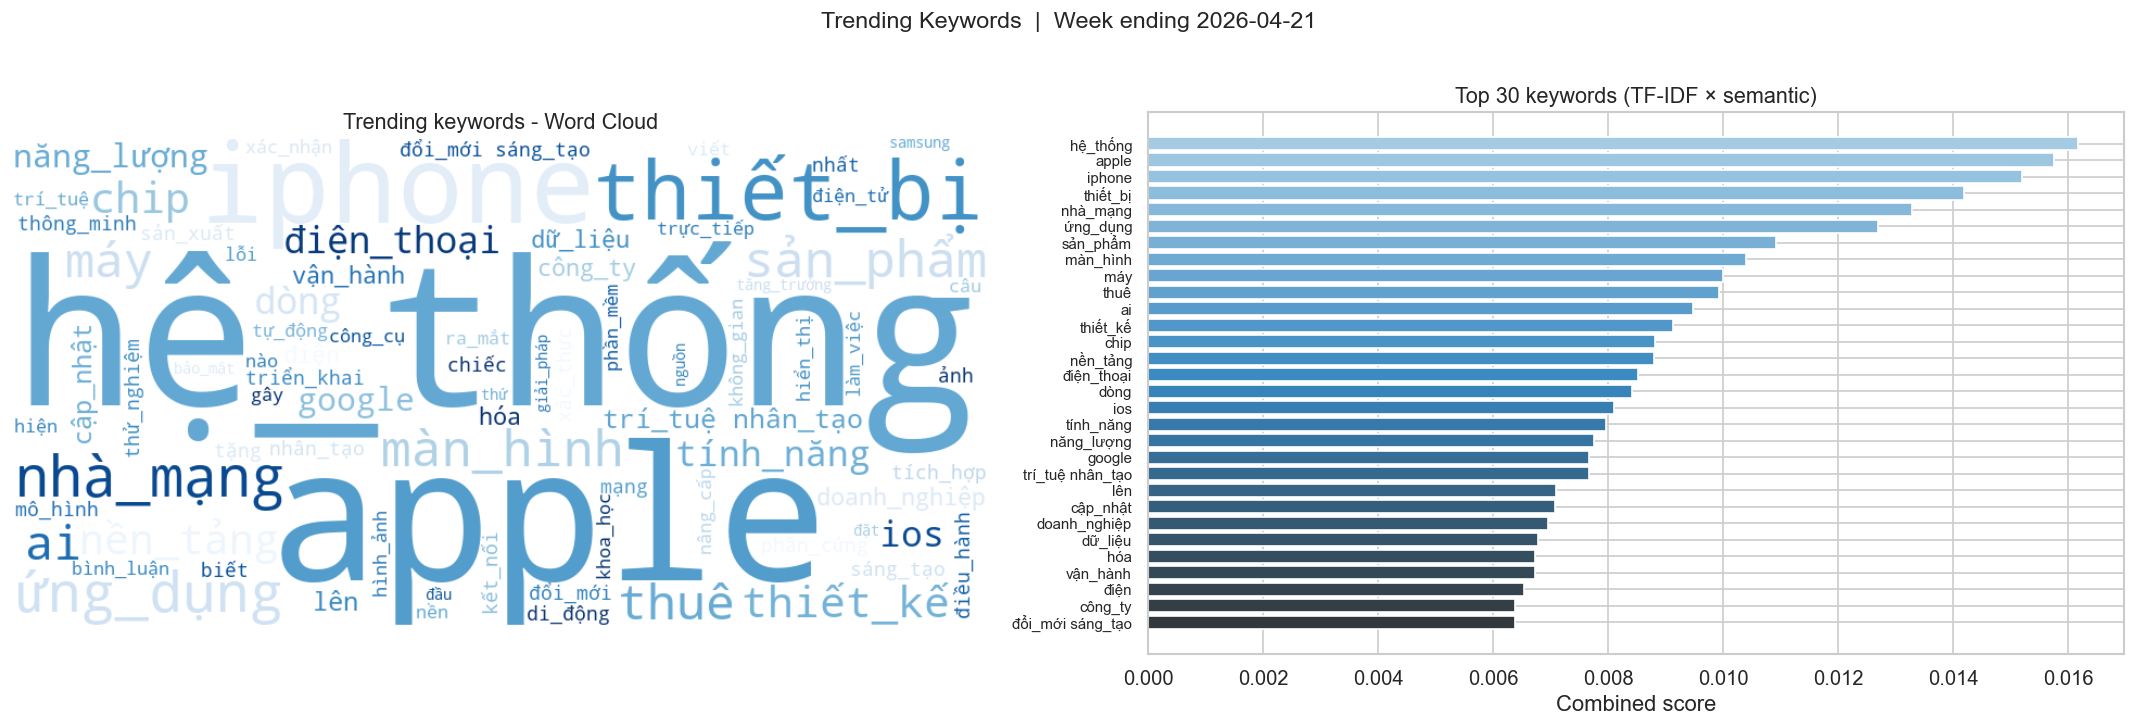

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

wc = WordCloud(width=900, height=450, background_color='white', colormap='Blues', max_words=80)
wc.generate_from_frequencies(dict(zip(kw_df['keyword'], kw_df['combined'])))
axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Trending keywords - Word Cloud', fontsize=13)

colors = sns.color_palette('Blues_d', len(top_kw))
axes[1].barh(top_kw['keyword'][::-1], top_kw['combined'][::-1], color=colors[::-1])
axes[1].set_title(f'Top {TOP_KEYWORDS} keywords (TF-IDF × semantic)', fontsize=13)
axes[1].set_xlabel('Combined score')
axes[1].tick_params(axis='y', labelsize=9)

plt.suptitle(f'Trending Keywords  |  Week ending {pd.Timestamp.now().strftime("%Y-%m-%d")}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

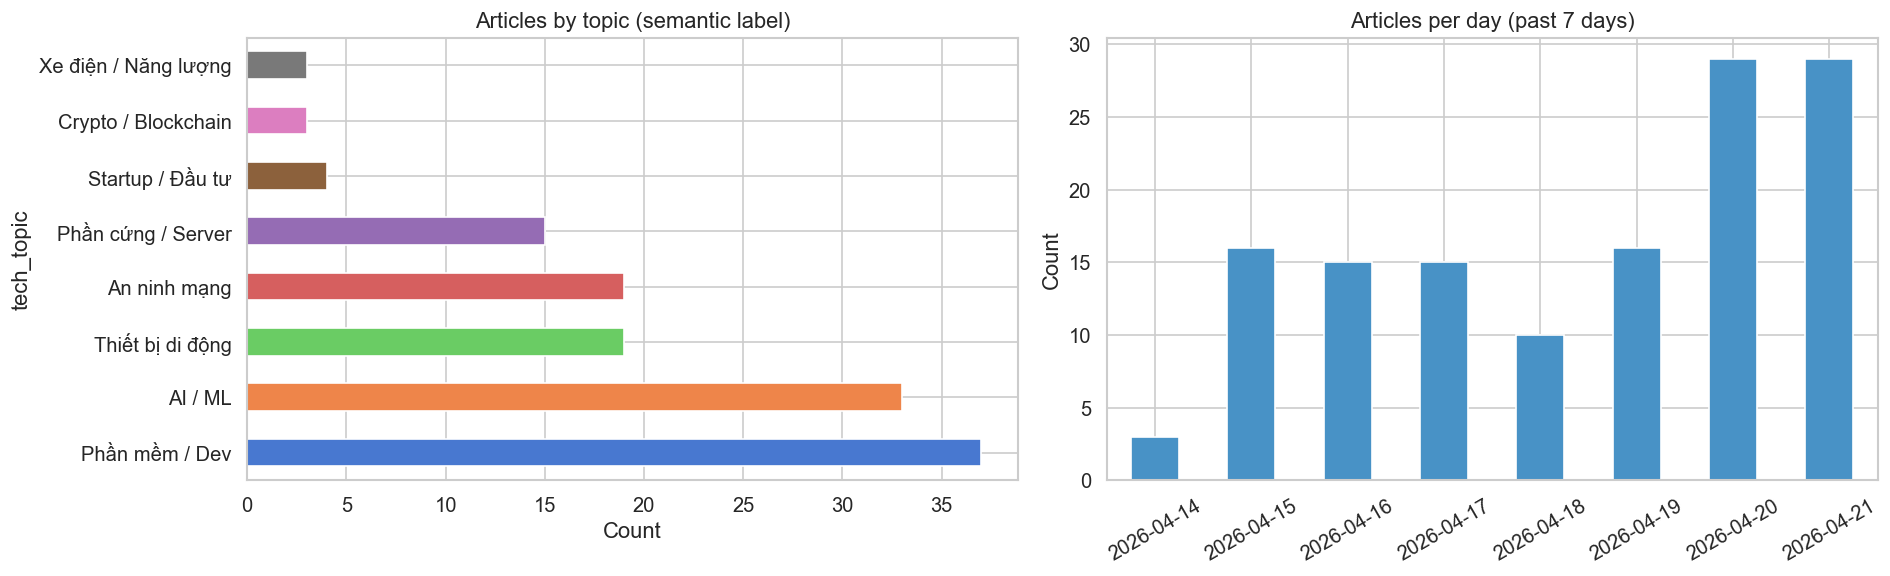

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

topic_counts = df_tech['tech_topic'].value_counts()
topic_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('muted', len(topic_counts)))
axes[0].set_title('Articles by topic (semantic label)')
axes[0].set_xlabel('Count')

daily = df_tech.groupby(df_tech['published_at'].dt.date).size()
daily.plot(kind='bar', ax=axes[1], color=sns.color_palette('Blues_d')[2])
axes[1].set_title(f'Articles per day (past {WINDOW_DAYS} days)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import silhouette_score

CHOSEN_K          = 6
EXPLORE_RADIUS    = 3
TOP_CLUSTER_KEYWORDS = 10

k_min = max(2, CHOSEN_K - EXPLORE_RADIUS)
k_max = CHOSEN_K + EXPLORE_RADIUS
CLUSTER_RANGE = range(k_min, k_max + 1)

inertia_list    = []
silhouette_list = []

for k in CLUSTER_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(tech_embeddings)
    inertia_list.append(km.inertia_)
    sil = silhouette_score(
        tech_embeddings, labels,
        sample_size=min(2000, len(tech_embeddings)),
        random_state=42,
    )
    silhouette_list.append(sil)
    marker = ' <-- chosen' if k == CHOSEN_K else ''
    print(f'  K={k:2d}  inertia={km.inertia_:,.1f}  silhouette={sil:.4f}{marker}')


  K= 3  inertia=72.5  silhouette=0.0536
  K= 4  inertia=70.4  silhouette=0.0403
  K= 5  inertia=67.6  silhouette=0.0503
  K= 6  inertia=65.3  silhouette=0.0602 <-- chosen
  K= 7  inertia=64.7  silhouette=0.0567
  K= 8  inertia=62.9  silhouette=0.0586
  K= 9  inertia=60.9  silhouette=0.0625


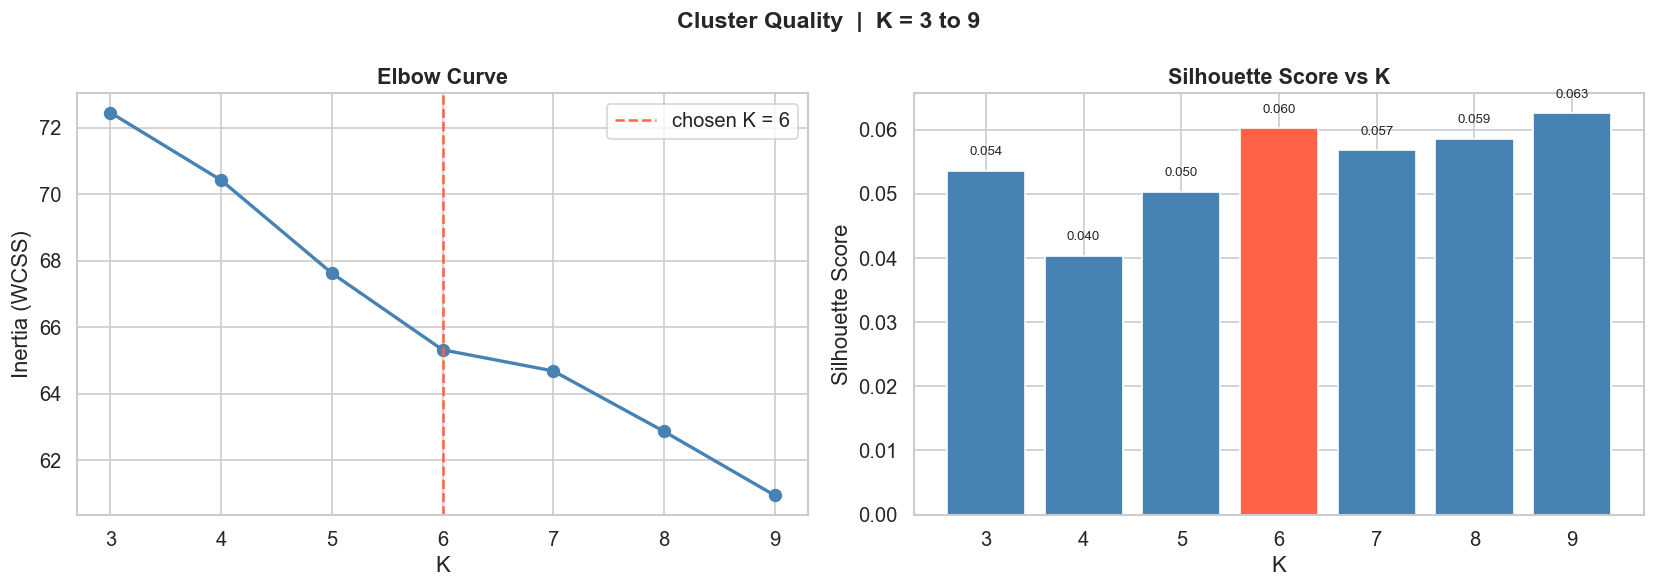

In [11]:
k_vals = list(CLUSTER_RANGE)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_vals, inertia_list, marker='o', color='steelblue', linewidth=2, markersize=7)
axes[0].axvline(CHOSEN_K, color='tomato', linestyle='--', label=f'chosen K = {CHOSEN_K}')
axes[0].set_title('Elbow Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend()
axes[0].set_xticks(k_vals)

bar_colors = ['tomato' if k == CHOSEN_K else 'steelblue' for k in k_vals]
axes[1].bar(k_vals, silhouette_list, color=bar_colors, edgecolor='white')
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(k_vals)
for x, y in zip(k_vals, silhouette_list):
    axes[1].text(x, y + 0.002, f'{y:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(f'Cluster Quality  |  K = {k_min} to {k_max}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [12]:
N_TOPIC_CLUSTERS = CHOSEN_K

kmeans         = KMeans(n_clusters=N_TOPIC_CLUSTERS, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(tech_embeddings)
df_tech        = df_tech.copy()
df_tech['cluster'] = cluster_labels

cluster_centers    = kmeans.cluster_centers_
cluster_sim        = cosine_similarity(cluster_centers, query_embeddings)
cluster_topic_idx  = cluster_sim.argmax(axis=1)
cluster_topic_name = [TOPIC_LABELS[i] for i in cluster_topic_idx]
cluster_topic_map  = {i: cluster_topic_name[i] for i in range(N_TOPIC_CLUSTERS)}
df_tech['cluster_topic'] = df_tech['cluster'].map(cluster_topic_map)

for c in range(N_TOPIC_CLUSTERS):
    n = (df_tech['cluster'] == c).sum()
    print(f'  cluster {c:2d}  [{cluster_topic_name[c]:20}]  {n:4d} articles')


  cluster  0  [Phần mềm / Dev      ]    23 articles
  cluster  1  [Phần mềm / Dev      ]    19 articles
  cluster  2  [AI / ML             ]    39 articles
  cluster  3  [An ninh mạng        ]    27 articles
  cluster  4  [Phần cứng / Server  ]     8 articles
  cluster  5  [Thiết bị di động    ]    17 articles


In [13]:
cluster_keywords = {}

for c in range(N_TOPIC_CLUSTERS):
    mask_c       = df_tech['cluster'].values == c
    cluster_docs = df_tech.loc[mask_c, 'tokenized'].tolist()
    if not cluster_docs:
        cluster_keywords[c] = []
        continue
    tfidf_c = TfidfVectorizer(
        max_features=TFIDF_MAX_FEATURES,
        ngram_range=TFIDF_NGRAM,
        token_pattern=r'(?u)\b\w\w+\b',
        min_df=1,
    )
    mat_c       = tfidf_c.fit_transform(cluster_docs)
    mean_scores = mat_c.mean(axis=0).A1
    top_idx     = mean_scores.argsort()[::-1][:TOP_CLUSTER_KEYWORDS]
    feat_c      = tfidf_c.get_feature_names_out()
    cluster_keywords[c] = [(feat_c[i], round(float(mean_scores[i]), 5)) for i in top_idx]

print(f'top {TOP_CLUSTER_KEYWORDS} keywords per cluster  (K={N_TOPIC_CLUSTERS})')
print('=' * 60)
for c in range(N_TOPIC_CLUSTERS):
    size = (df_tech['cluster'] == c).sum()
    print(f'\ncluster {c}  [{cluster_topic_name[c]}]  ({size} articles)')
    print('-' * 45)
    for rank, (kw, score) in enumerate(cluster_keywords[c], 1):
        print(f'  {rank:2d}.  {kw:<30}  {score:.5f}')
print('\n' + '=' * 60)


top 10 keywords per cluster  (K=6)

cluster 0  [Phần mềm / Dev]  (23 articles)
---------------------------------------------
   1.  ai                              0.09682
   2.  ảnh                             0.07935
   3.  gemini                          0.06964
   4.  tính_năng                       0.06947
   5.  google                          0.06867
   6.  ứng_dụng                        0.05962
   7.  dữ_liệu                         0.05850
   8.  công_cụ                         0.05483
   9.  tặng                            0.05462
  10.  trình_duyệt                     0.05080

cluster 1  [Phần mềm / Dev]  (19 articles)
---------------------------------------------
   1.  thiết_bị                        0.06695
   2.  máy                             0.06649
   3.  tốc_độ                          0.06377
   4.  giá                             0.06057
   5.  thị_trường                      0.06022
   6.  bitcoin                         0.05956
   7.  thiết_kế                  

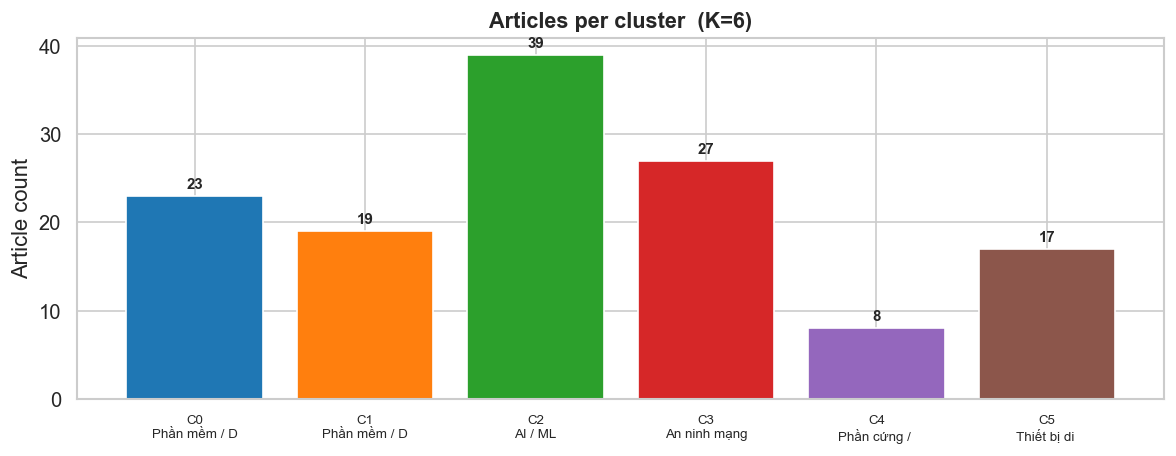

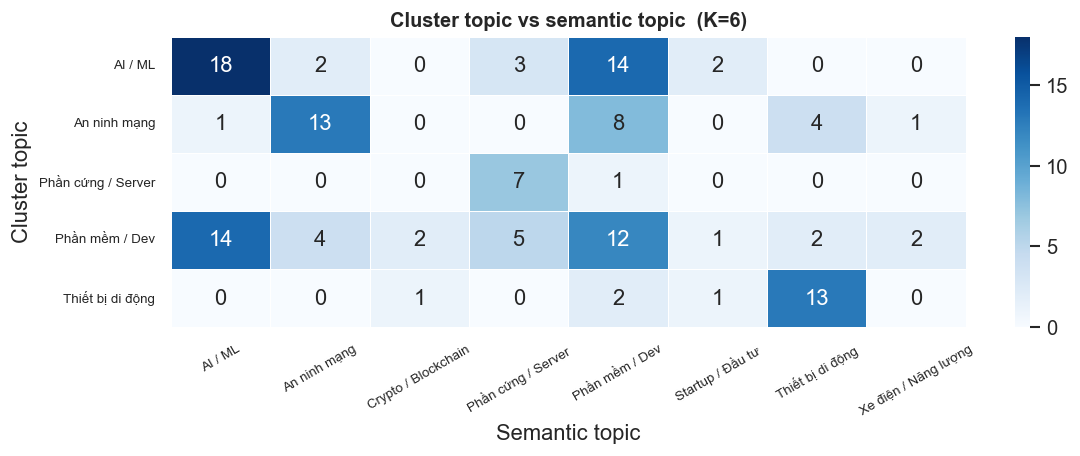

In [14]:
palette_c = sns.color_palette('tab10', N_TOPIC_CLUSTERS)

cluster_sizes      = [int((df_tech['cluster'] == c).sum()) for c in range(N_TOPIC_CLUSTERS)]
cluster_tick_labels = [f'C{c}\n{cluster_topic_name[c][:12]}' for c in range(N_TOPIC_CLUSTERS)]

fig, ax = plt.subplots(figsize=(max(10, N_TOPIC_CLUSTERS * 1.3), 4))
bars = ax.bar(
    cluster_tick_labels, cluster_sizes,
    color=[palette_c[c] for c in range(N_TOPIC_CLUSTERS)],
    edgecolor='white',
)
for bar, sz in zip(bars, cluster_sizes):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
        str(sz), ha='center', va='bottom', fontsize=9, fontweight='bold',
    )
ax.set_title(f'Articles per cluster  (K={N_TOPIC_CLUSTERS})', fontsize=13, fontweight='bold')
ax.set_ylabel('Article count')
ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
plt.show()

ct = pd.crosstab(df_tech['cluster_topic'], df_tech['tech_topic'])
fig, ax = plt.subplots(figsize=(max(10, len(ct.columns) * 1.2), max(4, len(ct) * 0.7)))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title(f'Cluster topic vs semantic topic  (K={N_TOPIC_CLUSTERS})', fontsize=12, fontweight='bold')
ax.set_xlabel('Semantic topic')
ax.set_ylabel('Cluster topic')
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()


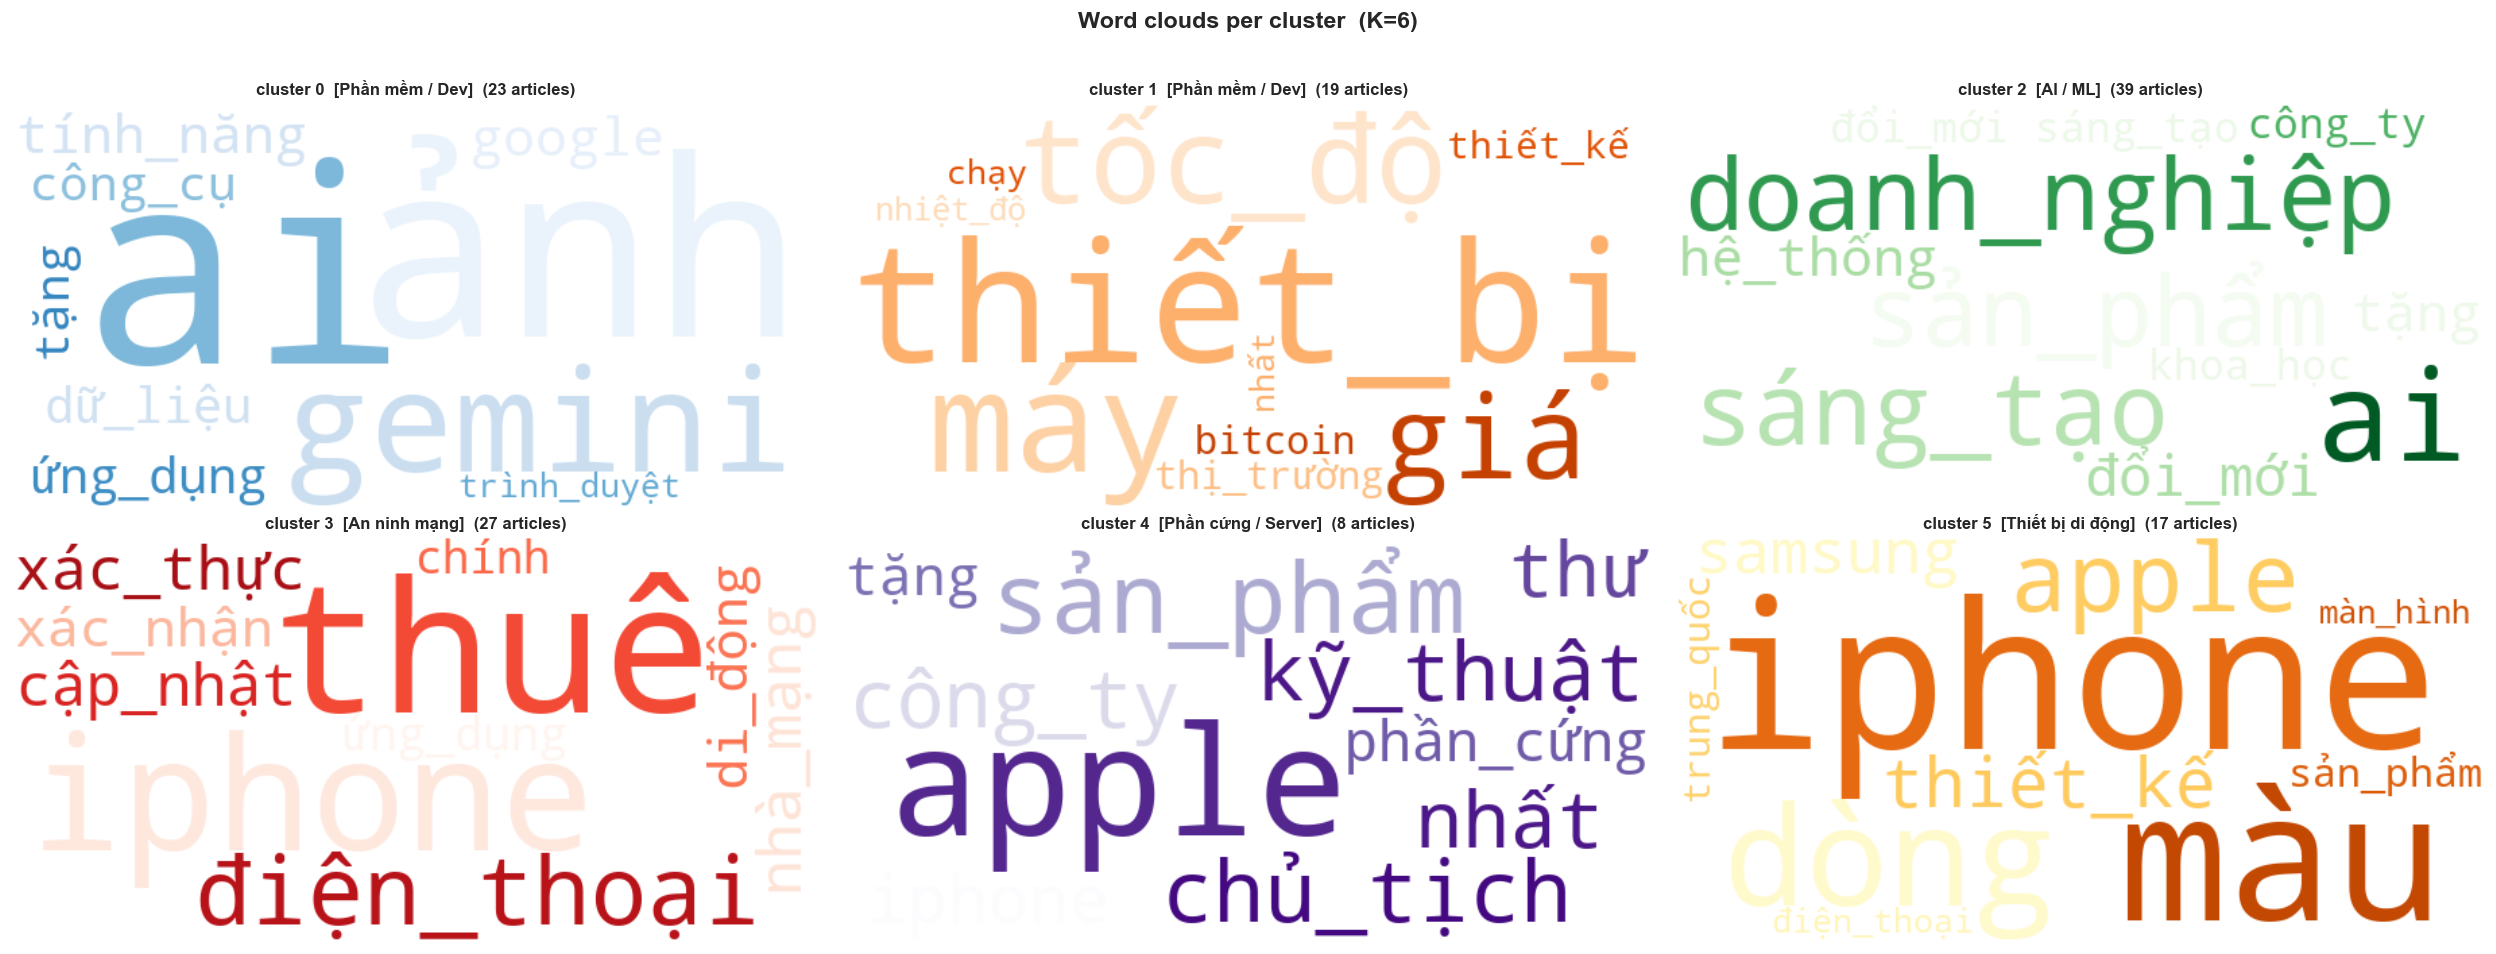

In [15]:
COLORMAPS = [
    'Blues','Oranges','Greens','Reds','Purples',
    'YlOrBr','BuGn','RdPu','GnBu','OrRd',
]

ncols     = min(3, N_TOPIC_CLUSTERS)
nrows     = (N_TOPIC_CLUSTERS + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows))
axes_flat = np.array(axes).flatten() if N_TOPIC_CLUSTERS > 1 else [axes]

for c in range(N_TOPIC_CLUSTERS):
    ax        = axes_flat[c]
    freq_dict = dict(cluster_keywords[c])
    if freq_dict:
        wc_c = WordCloud(
            width=600, height=300,
            background_color='white',
            colormap=COLORMAPS[c % len(COLORMAPS)],
            max_words=30,
        ).generate_from_frequencies(freq_dict)
        ax.imshow(wc_c, interpolation='bilinear')
    else:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')
    size_c = (df_tech['cluster'] == c).sum()
    ax.set_title(
        f'cluster {c}  [{cluster_topic_name[c]}]  ({size_c} articles)',
        fontsize=10, fontweight='bold',
    )

for idx in range(N_TOPIC_CLUSTERS, len(axes_flat)):
    axes_flat[idx].axis('off')

fig.suptitle(f'Word clouds per cluster  (K={N_TOPIC_CLUSTERS})', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [16]:
highlight_rows = []

for c in range(N_TOPIC_CLUSTERS):
    cluster_df = df_tech[df_tech['cluster'] == c].copy()
    cluster_emb = tech_embeddings[df_tech['cluster'].values == c]
    center = cluster_centers[c]
    cluster_df['dist_to_center'] = cosine_similarity(cluster_emb, center.reshape(1, -1)).flatten()
    top = cluster_df.nlargest(TOP_NEWS_PER_CLUSTER, 'dist_to_center')
    highlight_rows.append(top)

df_highlights_cluster = pd.concat(highlight_rows).drop_duplicates(subset=['url'])

df_highlights_global = df_tech.nlargest(TOP_NEWS_GLOBAL, 'tech_score')

df_highlights = (
    pd.concat([df_highlights_cluster, df_highlights_global])
    .drop_duplicates(subset=['url'])
    .nlargest(HIGHLIGHT_TOP_N, 'tech_score')
    .reset_index(drop=True)
)

print(f'Highlighted news: {len(df_highlights)} articles')
for _, row in df_highlights.iterrows():
    print(f"  [{row['tech_topic']:20}] score={row['tech_score']:.3f}  {row['title'][:80]}")
    print(f"    {row['url']}")

Highlighted news: 10 articles
  [AI / ML             ] score=0.575  Microsoft chính thức vận hành trung tâm AI mạnh nhất thế giới
    https://dantri.com.vn/cong-nghe/microsoft-chinh-thuc-van-hanh-trung-tam-ai-manh-nhat-the-gioi-20260420135803112.htm
  [Phần cứng / Server  ] score=0.568  ROG Flow Z13-KJP và TUF Gaming A14 2026 trang bị AMD Ryzen AI Max+ ra mắt tại Vi
    https://trainghiemso.vn/rog-flow-z13-kjp-va-tuf-gaming-a14-2026-trang-bi-amd-ryzen-ai-max-ra-mat-tai-viet-nam/
  [AI / ML             ] score=0.557  Lợi thế khi OpenClaw triển khai trên Cloud
    https://vnexpress.net/loi-the-khi-openclaw-trien-khai-tren-cloud-5063333.html
  [Phần mềm / Dev      ] score=0.550  Google tích hợp AI vào Chrome, tìm kiếm không cần mở trang
    https://tuoitre.vn/google-tich-hop-ai-vao-chrome-tim-kiem-khong-can-mo-trang-20260418162644167.htm
  [AI / ML             ] score=0.549  Google hợp tác Marvell phát triển chip AI giải bài toán hiệu năng suy luận
    https://dantri.com.vn/cong-nghe/goog

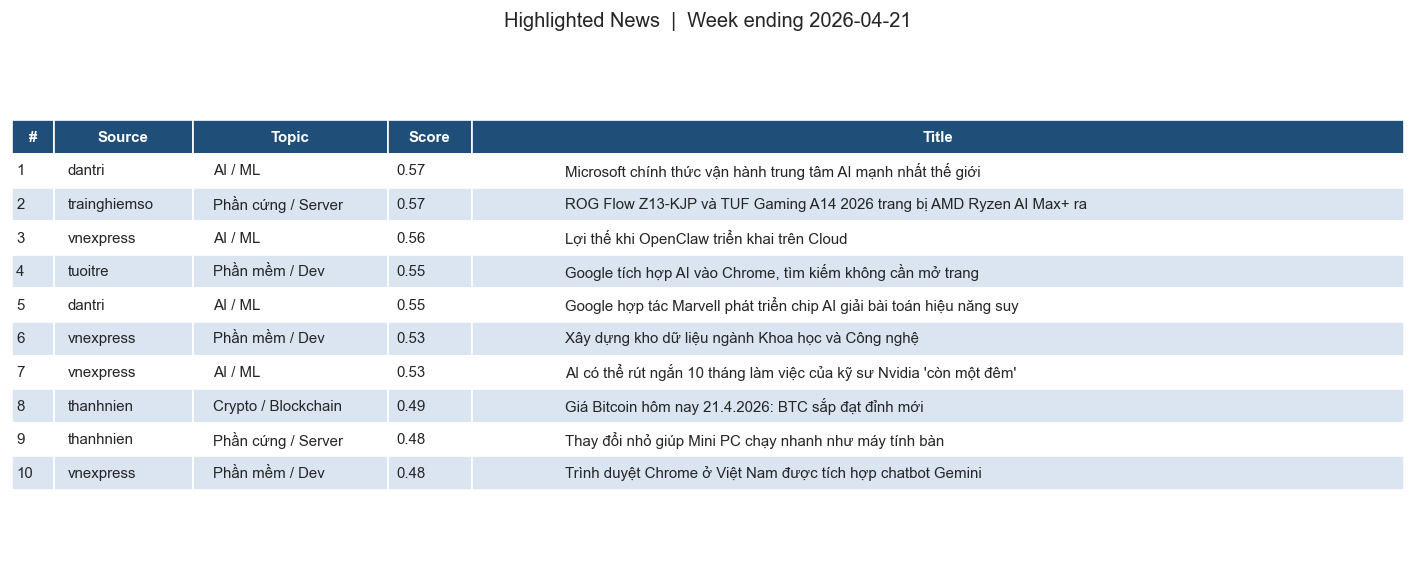

In [17]:
fig, ax = plt.subplots(figsize=(12, max(4, len(df_highlights) * 0.5)))
ax.axis('off')

table_data = [
    [f"{i+1}", row['source'], row['tech_topic'], f"{row['tech_score']:.2f}", row['title'][:70]]
    for i, (_, row) in enumerate(df_highlights.iterrows())
]
cols = ['#', 'Source', 'Topic', 'Score', 'Title']
tbl = ax.table(
    cellText=table_data,
    colLabels=cols,
    cellLoc='left',
    loc='center',
    colWidths=[0.03, 0.1, 0.14, 0.06, 0.67],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1f4e79')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#dbe5f1')
    cell.set_edgecolor('white')

ax.set_title(f'Highlighted News  |  Week ending {pd.Timestamp.now().strftime("%Y-%m-%d")}', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

In [18]:
topic_dist = df_tech['tech_topic'].value_counts()
dominant_topic = topic_dist.index[0]
dominant_pct = topic_dist.iloc[0] / len(df_tech) * 100

top3_kw = top_kw['keyword'].tolist()[:3]
top5_highlights = df_highlights.head(EXEC_SUMMARY_MAX_ARTICLES)

week_str = f"{(pd.Timestamp.now() - pd.Timedelta(days=WINDOW_DAYS)).strftime('%d/%m/%Y')} - {pd.Timestamp.now().strftime('%d/%m/%Y')}"

exec_lines = [
    f"WEEKLY TECH NEWS REPORT  |  {week_str}",
    "=" * 70,
    "",
    "EXECUTIVE SUMMARY",
    "-" * 40,
    f"Tuần qua ghi nhận {len(df_tech):,} bài viết công nghệ từ {df_tech['source'].nunique()} nguồn.",
    f"Chủ đề nổi bật nhất: {dominant_topic} ({dominant_pct:.0f}% số bài).",
    f"Từ khóa xu hướng hàng đầu: {', '.join(top3_kw)}.",
    "",
    "TRENDING KEYWORDS (TOP 10)",
    "-" * 40,
]
for i, row in top_kw.head(10).iterrows():
    exec_lines.append(f"  {i+1:2}. {row['keyword']:<30}  score={row['combined']:.4f}")

exec_lines += [
    "",
    "HIGHLIGHTED NEWS",
    "-" * 40,
]
for i, (_, row) in enumerate(df_highlights.iterrows()):
    exec_lines.append(f"  {i+1:2}. [{row['tech_topic']}] {row['title']}")
    summary_snippet = row['content'][:200].replace('\n', ' ')
    exec_lines.append(f"      {summary_snippet}...")
    exec_lines.append(f"      Source: {row['source']}  |  {row['url']}")
    exec_lines.append("")

report_text = '\n'.join(exec_lines)
print(report_text)

WEEKLY TECH NEWS REPORT  |  14/04/2026 - 21/04/2026

EXECUTIVE SUMMARY
----------------------------------------
Tuần qua ghi nhận 133 bài viết công nghệ từ 6 nguồn.
Chủ đề nổi bật nhất: Phần mềm / Dev (28% số bài).
Từ khóa xu hướng hàng đầu: hệ_thống, apple, iphone.

TRENDING KEYWORDS (TOP 10)
----------------------------------------
   1. hệ_thống                        score=0.0162
   2. apple                           score=0.0158
   3. iphone                          score=0.0152
   4. thiết_bị                        score=0.0142
   5. nhà_mạng                        score=0.0133
   6. ứng_dụng                        score=0.0127
   7. sản_phẩm                        score=0.0109
   8. màn_hình                        score=0.0104
   9. máy                             score=0.0100
  10. thuê                            score=0.0099

HIGHLIGHTED NEWS
----------------------------------------
   1. [AI / ML] Microsoft chính thức vận hành trung tâm AI mạnh nhất thế giới
      (Dân trí) -

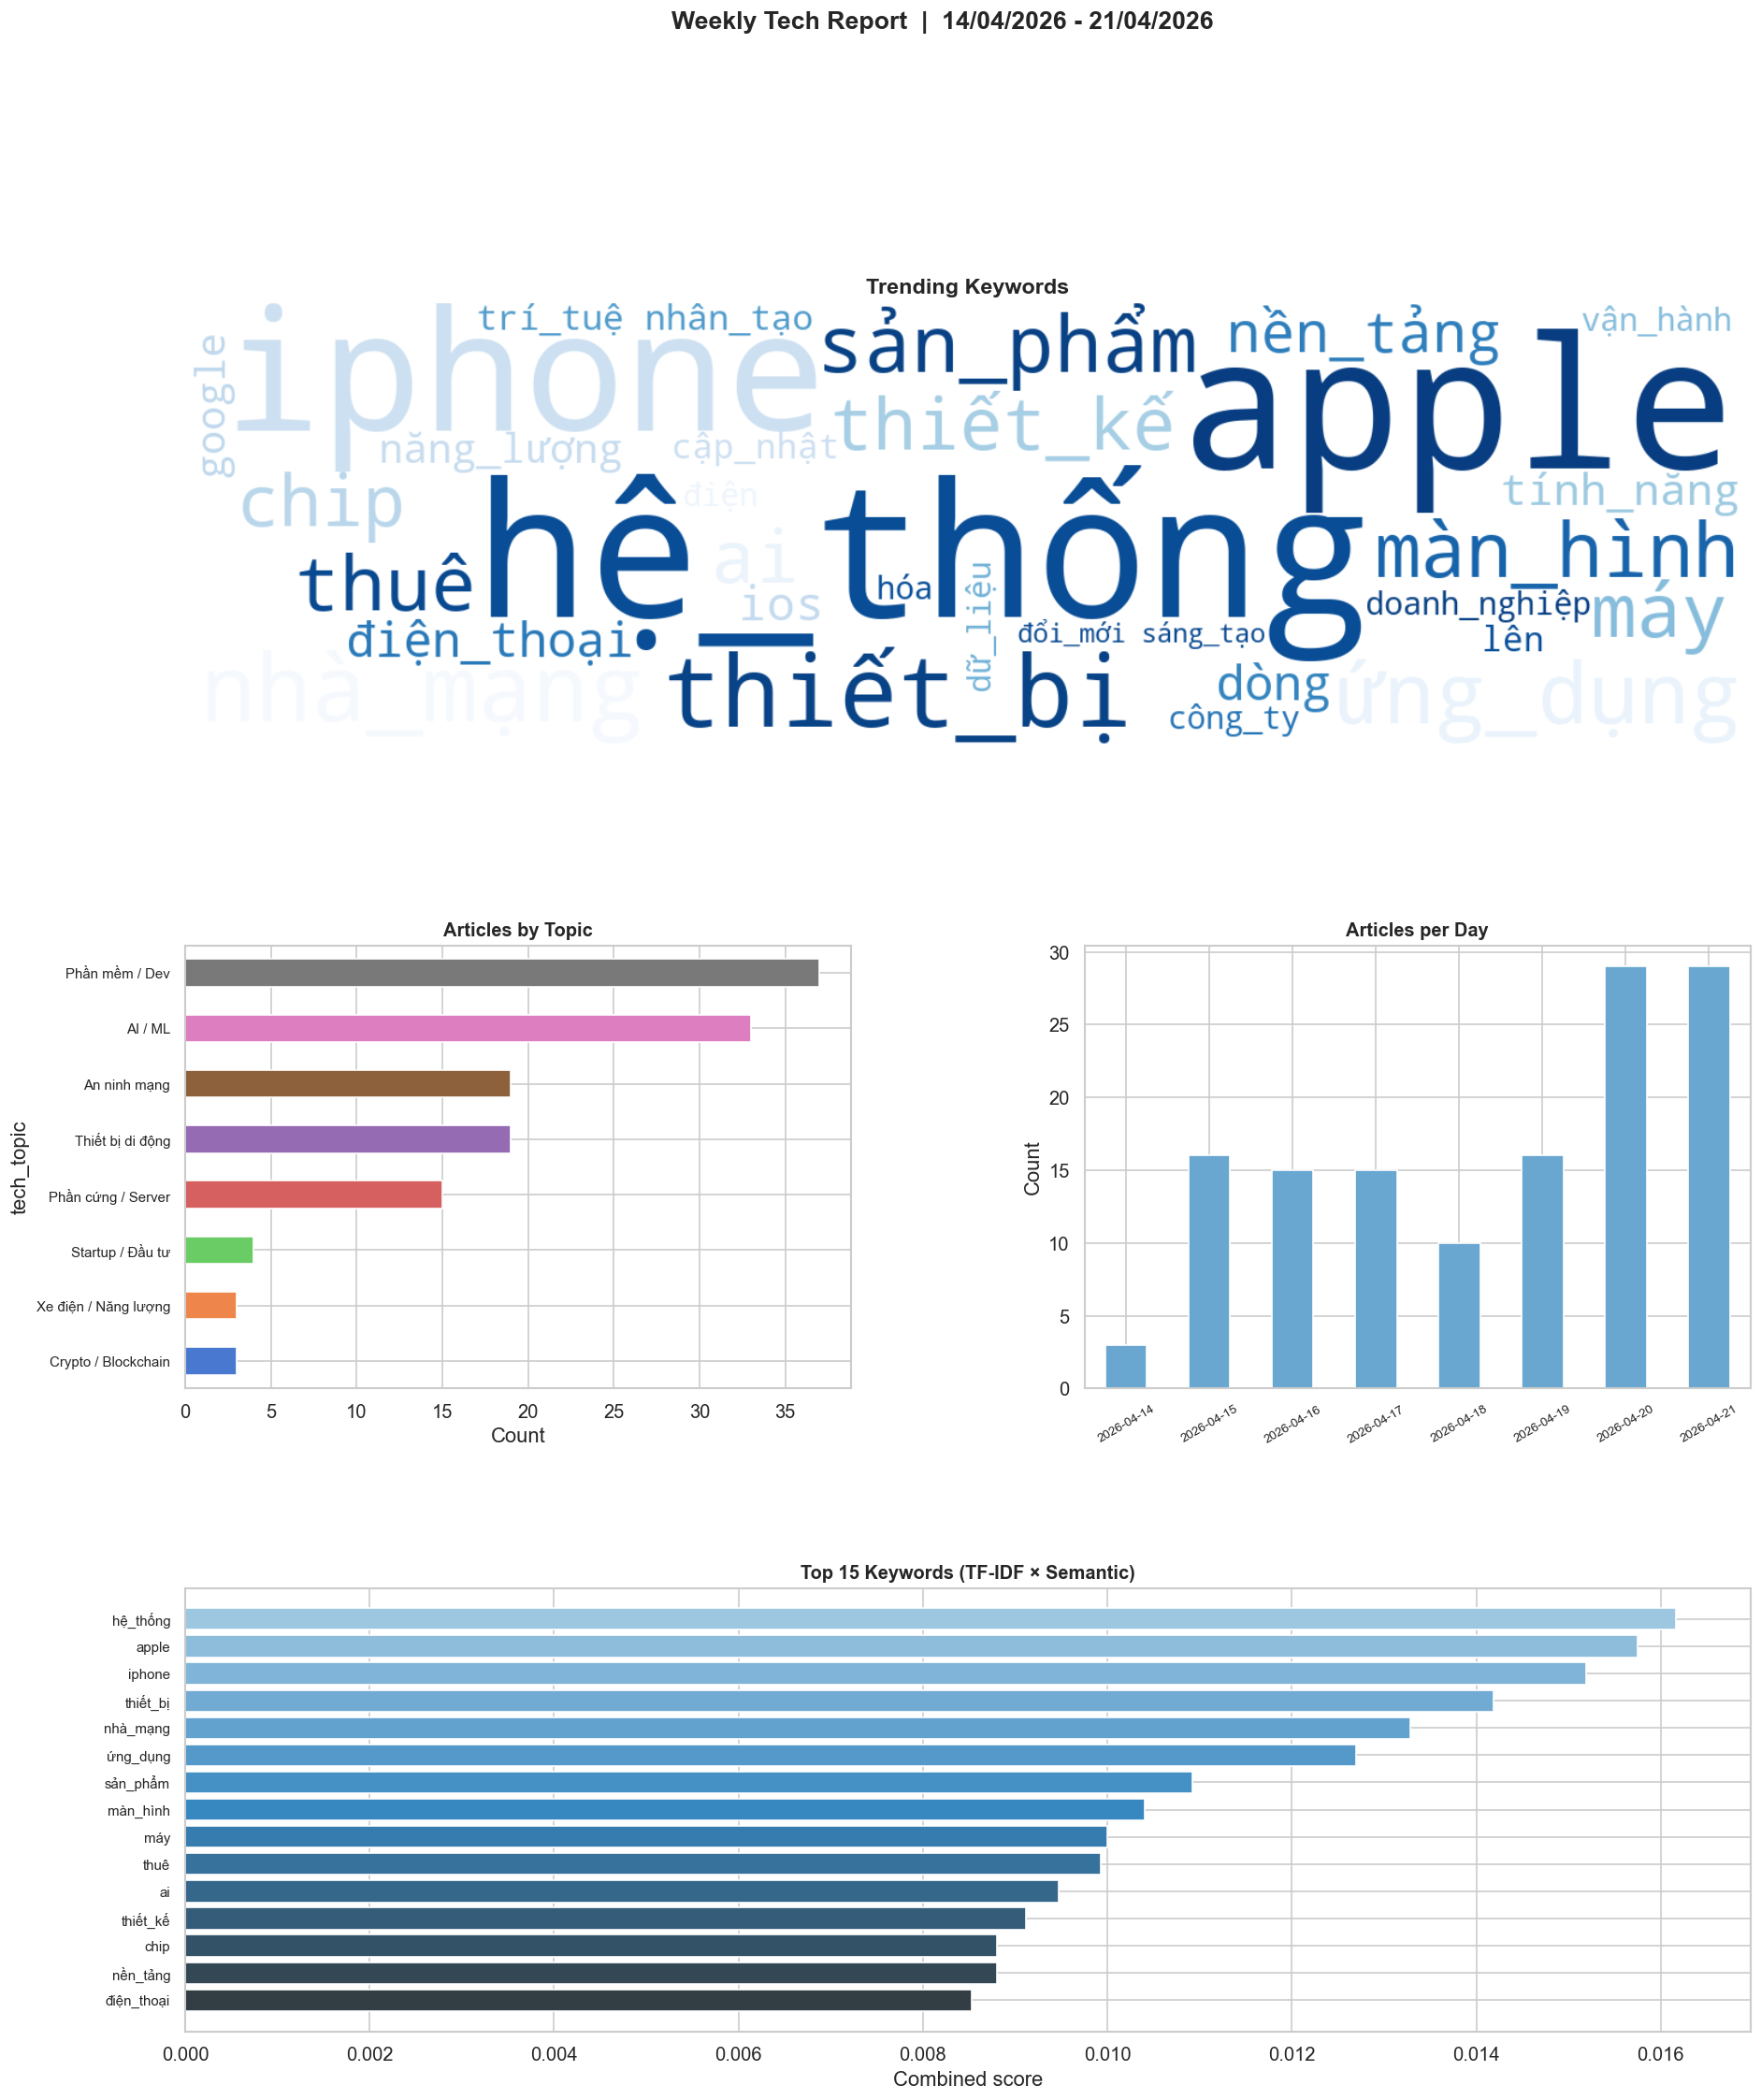

Saved: weekly_report_summary.png


In [19]:
fig = plt.figure(figsize=(18, 20))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

ax_wc = fig.add_subplot(gs[0, :])
wc2 = WordCloud(width=1400, height=400, background_color='white', colormap='Blues', max_words=60)
wc2.generate_from_frequencies(dict(zip(top_kw['keyword'], top_kw['combined'])))
ax_wc.imshow(wc2, interpolation='bilinear')
ax_wc.axis('off')
ax_wc.set_title('Trending Keywords', fontsize=14, fontweight='bold')

ax_topic = fig.add_subplot(gs[1, 0])
topic_counts_sorted = df_tech['tech_topic'].value_counts().sort_values()
palette = sns.color_palette('muted', len(topic_counts_sorted))
topic_counts_sorted.plot(kind='barh', ax=ax_topic, color=palette)
ax_topic.set_title('Articles by Topic', fontsize=12, fontweight='bold')
ax_topic.set_xlabel('Count')
ax_topic.tick_params(axis='y', labelsize=9)

ax_daily = fig.add_subplot(gs[1, 1])
daily2 = df_tech.groupby(df_tech['published_at'].dt.date).size()
daily2.plot(kind='bar', ax=ax_daily, color=sns.color_palette('Blues_d')[1])
ax_daily.set_title('Articles per Day', fontsize=12, fontweight='bold')
ax_daily.set_xlabel('')
ax_daily.set_ylabel('Count')
ax_daily.tick_params(axis='x', rotation=30, labelsize=8)

ax_kw = fig.add_subplot(gs[2, :])
top15 = kw_df.head(15)
colors_kw = sns.color_palette('Blues_d', len(top15))
ax_kw.barh(top15['keyword'][::-1], top15['combined'][::-1], color=colors_kw[::-1])
ax_kw.set_title('Top 15 Keywords (TF-IDF × Semantic)', fontsize=12, fontweight='bold')
ax_kw.set_xlabel('Combined score')
ax_kw.tick_params(axis='y', labelsize=9)

fig.suptitle(
    f'Weekly Tech Report  |  {week_str}',
    fontsize=16, fontweight='bold', y=1.01
)
plt.savefig('weekly_report_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: weekly_report_summary.png')

In [20]:
report_json = {
    'week': week_str,
    'generated_at': datetime.now(timezone.utc).isoformat(),
    'stats': {
        'total_tech_articles': int(len(df_tech)),
        'sources': int(df_tech['source'].nunique()),
        'dominant_topic': dominant_topic,
        'dominant_topic_pct': round(float(dominant_pct), 1),
    },
    'executive_summary': {
        'landscape': f"{len(df_tech):,} bài viết công nghệ từ {df_tech['source'].nunique()} nguồn trong tuần {week_str}.",
        'dominant_topic': dominant_topic,
        'top_keywords': top3_kw,
    },
    'trending_keywords': [
        {'rank': i+1, 'keyword': row['keyword'], 'score': round(float(row['combined']), 5)}
        for i, row in top_kw.iterrows()
    ],
    'highlighted_news': [
        {
            'rank': i+1,
            'title': row['title'],
            'source': row['source'],
            'url': row['url'],
            'published_at': str(row['published_at']),
            'topic': row['tech_topic'],
            'tech_score': round(float(row['tech_score']), 4),
            'summary': row['content'][:300].replace('\n', ' '),
        }
        for i, (_, row) in enumerate(df_highlights.iterrows())
    ],
}

with open('weekly_report.json', 'w', encoding='utf-8') as f:
    json.dump(report_json, f, ensure_ascii=False, indent=2)

print('Saved: weekly_report.json')
print(json.dumps(report_json['executive_summary'], ensure_ascii=False, indent=2))

Saved: weekly_report.json
{
  "landscape": "133 bài viết công nghệ từ 6 nguồn trong tuần 14/04/2026 - 21/04/2026.",
  "dominant_topic": "Phần mềm / Dev",
  "top_keywords": [
    "hệ_thống",
    "apple",
    "iphone"
  ]
}
